## Analisis_anual 
para entender como ha cambiado el dolar es necesiaro hacer un analisis por año asi podremos sectorizar Problematicas que han afectado el dolar

In [48]:
import pandas as pd

df = pd.read_parquet("../Data/processed/df_5.parquet")
print(df)

        Periodo      TRM
0    2021-01-02  3432.50
1    2021-01-03  3432.50
2    2021-01-04  3432.50
3    2021-01-05  3420.78
4    2021-01-06  3450.74
...         ...      ...
2009 2026-07-04  3334.93
2010 2026-07-05  3334.93
2011 2026-07-06  3334.93
2012 2026-07-07  3350.68
2013 2026-07-08  3335.50

[2014 rows x 2 columns]


## 2) Segmentación por año

Dividimos la serie en subconjuntos anuales y los guardamos en el diccionario `Anaules`, donde la **clave es el año** (2021–2026) y el **valor es el `DataFrame`** con los registros de ese año. Así podremos analizar y graficar cada período de forma independiente.

In [49]:
import matplotlib.pyplot as plt
Anaules = dict()

for i in (2021,2022,2023,2024,2025,2026):
    Anaules[i] = df[df["Periodo"].dt.year == i]
    
Anaules

{2021:        Periodo      TRM
 0   2021-01-02  3432.50
 1   2021-01-03  3432.50
 2   2021-01-04  3432.50
 3   2021-01-05  3420.78
 4   2021-01-06  3450.74
 ..         ...      ...
 359 2021-12-27  3994.15
 360 2021-12-28  3989.41
 361 2021-12-29  4004.00
 362 2021-12-30  4023.68
 363 2021-12-31  3981.16
 
 [364 rows x 2 columns],
 2022:        Periodo      TRM
 364 2022-01-01  3981.16
 365 2022-01-02  3981.16
 366 2022-01-03  3981.16
 367 2022-01-04  4082.75
 368 2022-01-05  4084.11
 ..         ...      ...
 724 2022-12-27  4745.04
 725 2022-12-28  4766.82
 726 2022-12-29  4765.92
 727 2022-12-30  4810.20
 728 2022-12-31  4810.20
 
 [365 rows x 2 columns],
 2023:         Periodo      TRM
 729  2023-01-01  4810.20
 730  2023-01-02  4810.20
 731  2023-01-03  4810.20
 732  2023-01-04  4842.26
 733  2023-01-05  4924.00
 ...         ...      ...
 1089 2023-12-27  3871.45
 1090 2023-12-28  3844.81
 1091 2023-12-29  3822.05
 1092 2023-12-30  3822.05
 1093 2023-12-31  3822.05
 
 [365 rows x 2

## 3) Función de visualización y variación anual

Definimos la función `graficar_trm`, que para cualquier `DataFrame` de la TRM:

- traza la evolución del dólar en el tiempo;
- señala con líneas verticales los puntos **máximo** (rojo) y **mínimo** (verde);
- calcula la **variación punta a punta** —del primer al último día del período— e indica si el peso se **apreció** o **depreció**.

Reutilizaremos esta función para cada año del diccionario `Anaules`.

In [50]:
def graficar_trm(df, titulo="Evolución de la TRM (USD/COP)"):
    # ordenar por fecha para que el primero/ultimo sean correctos
    df = df.sort_values("Periodo")

    plt.figure(figsize=(12, 5))              # tamaño del canvas (ancho, alto)
    plt.plot(df["Periodo"], df["TRM"])

    # punto mas alto del periodo
    idx_max = df["TRM"].idxmax()
    fecha_max = df.loc[idx_max, "Periodo"]
    valor_max = df.loc[idx_max, "TRM"]

    # punto mas bajo del periodo
    idx_min = df["TRM"].idxmin()
    fecha_min = df.loc[idx_min, "Periodo"]
    valor_min = df.loc[idx_min, "TRM"]

    # linea en lo mas alto
    plt.axvline(fecha_max, color="red", linestyle="--", alpha=0.7)   # linea VERTICAL en el maximo
    plt.scatter(fecha_max, valor_max, color="red", zorder=5)

    # linea en lo mas bajo
    plt.axvline(fecha_min, color="green", linestyle="--", alpha=0.8)

    plt.grid(alpha=0.3)
    plt.title(titulo)
    plt.xlabel("Tiempo")
    plt.ylabel("Valor Dolar")
    plt.show()

    # --- apreciacion / depreciacion (punta a punta, perspectiva del peso) ---
    trm_inicio = df["TRM"].iloc[0]
    trm_fin = df["TRM"].iloc[-1]
    variacion = (trm_fin - trm_inicio) / trm_inicio * 100

    if variacion > 0:
        situacion = "DEPRECIACIÓN del peso (la TRM subió)"
    elif variacion < 0:
        situacion = "APRECIACIÓN del peso (la TRM bajó)"
    else:
        situacion = "sin cambio"

    print(f'''
    El punto donde el dolar estuvo mas alto fue en el {str(fecha_max)[:10]} con un valor de {valor_max}

    El punto donde el dolar estuvo mas bajo fue en el {str(fecha_min)[:10]} con un valor de {valor_min}

    Del {str(df["Periodo"].iloc[0])[:10]} al {str(df["Periodo"].iloc[-1])[:10]}:
    la TRM pasó de {trm_inicio:,.2f} a {trm_fin:,.2f} → variación de {variacion:+.2f}%  ({situacion})
''')


## 2021: Rebote pos-pandemia y tensión social

En 2021 la TRM abrió en **\$3.420,78** y cerró en **\$4.023,68**, lo que representa una **depreciación del peso cercana al 15,98 %**. El año estuvo marcado por dos fuerzas opuestas: un fuerte rebote económico —el PIB creció **10,6 %**, según el DANE— y episodios de marcada inestabilidad social.

Entre abril y mayo estalló el **Paro Nacional**, detonado inicialmente por la reforma tributaria propuesta por el gobierno Duque. Durante ese período la TRM se mantuvo por encima de **\$3.740,14**. En los meses posteriores al paro se intensificó la violencia contra la población civil, con distintos hechos de orden público.

Este comportamiento **sugiere una correlación** entre la incertidumbre política y la depreciación del peso; sin embargo, no puede afirmarse una **causalidad directa**, ya que en el tipo de cambio también influyen factores externos (precio del petróleo, política monetaria de la Reserva Federal, etc.).

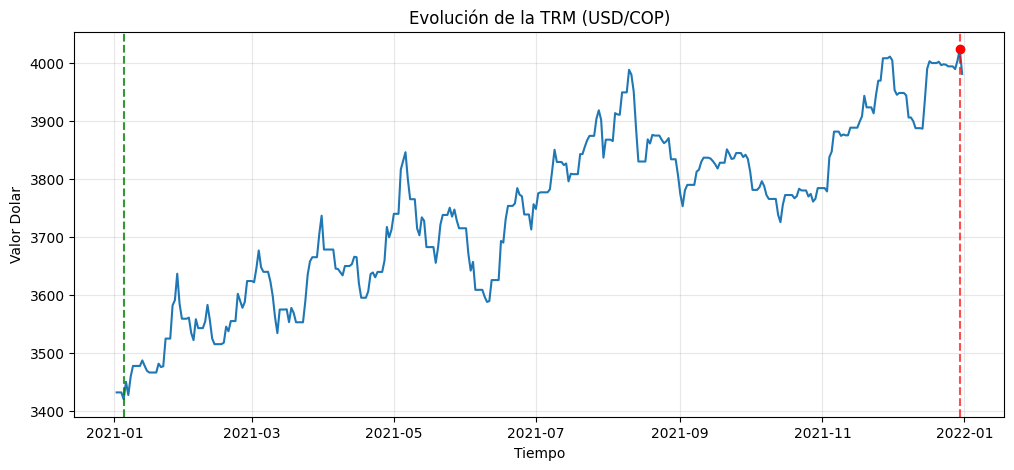


    El punto donde el dolar estuvo mas alto fue en el 2021-12-30 con un valor de 4023.68

    El punto donde el dolar estuvo mas bajo fue en el 2021-01-05 con un valor de 3420.78

    Del 2021-01-02 al 2021-12-31:
    la TRM pasó de 3,432.50 a 3,981.16 → variación de +15.98%  (DEPRECIACIÓN del peso (la TRM subió))



In [53]:
graficar_trm(Anaules[2021])

## 2022: _(pendiente de análisis)_

En 2022 la TRM abrió en **\$3.981,16** y cerró en **\$4.810,20**, una fuerte **depreciación del peso**.

> _Completar con el contexto del año: ciclo de alzas de tasas de la Reserva Federal, cambio de gobierno en Colombia (elecciones presidenciales de 2022), evolución del precio del petróleo, etc._